In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Python_Analytics/CSV

Mounted at /content/drive
/content/drive/MyDrive/Python_Analytics/CSV


In [ ]:
sales_data = pd.read_csv("sales_data_updated.csv")
print(sales_data)


       order_date      time  aging  customer_id gender device_type  \
0      2018-01-01  10:11:40    5.0        29317   Male         Web   
1      2018-01-01  22:30:44    7.0        42270   Male         Web   
2      2018-01-01  21:55:31   10.0        14563   Male         Web   
3      2018-01-01  13:57:15    9.0        58601   Male         Web   
4      2018-01-01  15:17:41    2.0        48342   Male         Web   
...           ...       ...    ...          ...    ...         ...   
51285  2018-12-30  16:20:22    5.0        88891   Male         Web   
51286  2018-12-30  11:52:02    7.0        74259   Male         Web   
51287  2018-12-30  15:06:46    5.0        62596   Male         Web   
51288  2018-12-30  15:36:49    1.0        77349   Male         Web   
51289  2018-12-30  13:49:02    7.0        79637   Male         Web   

      customer_login_type    product_category                 product  sales  \
0                  Member  Auto & Accessories       Car Media Players  140.0   

In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_date           51290 non-null  datetime64[ns]
 1   time                 51290 non-null  object        
 2   aging                51289 non-null  float64       
 3   customer_id          51290 non-null  int64         
 4   gender               51290 non-null  object        
 5   device_type          51290 non-null  object        
 6   customer_login_type  51290 non-null  object        
 7   product_category     51290 non-null  object        
 8   product              51290 non-null  object        
 9   sales                51289 non-null  float64       
 10  quantity             51288 non-null  float64       
 11  discount             51289 non-null  float64       
 12  profit               51290 non-null  float64       
 13  shipping_cost        51289 non-

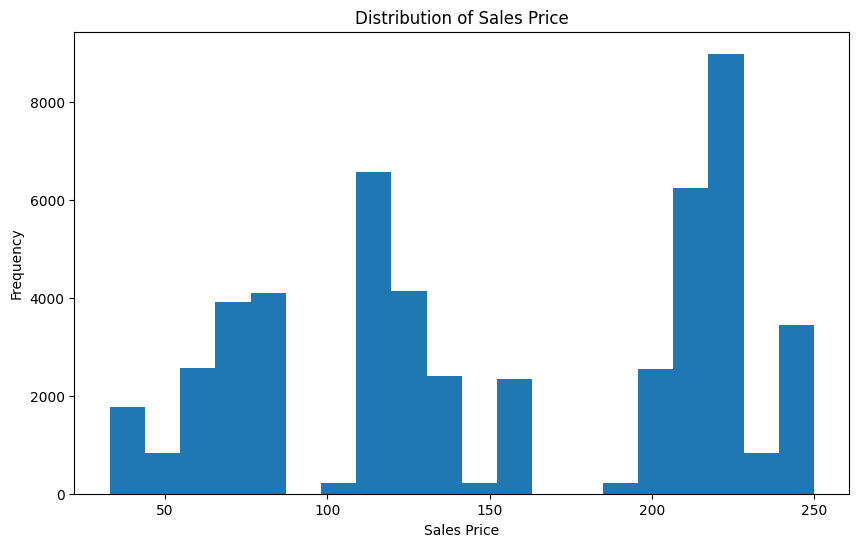

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    sales_data["sales"],
    bins=20
)

plt.title("Distribution of Sales Price")
plt.xlabel("Sales Price")
plt.ylabel("Frequency")

plt.show()


Розподіл ціни продажу є нерівномірним із кількома піками, що вказує на наявність кількох основних цінових категорій товарів. Продажі з високою ціною трапляються досить часто, тоді як низькі ціни зустрічаються рідше.

In [ ]:
sales_data['order_date'].dtype

dtype('O')

In [ ]:
sales_data["order_date"] = pd.to_datetime(sales_data["order_date"])
sales_data['order_date']


,order_date
0,2018-01-01
1,2018-01-01
2,2018-01-01
3,2018-01-01
4,2018-01-01
...,...
51285,2018-12-30
51286,2018-12-30
51287,2018-12-30
51288,2018-12-30


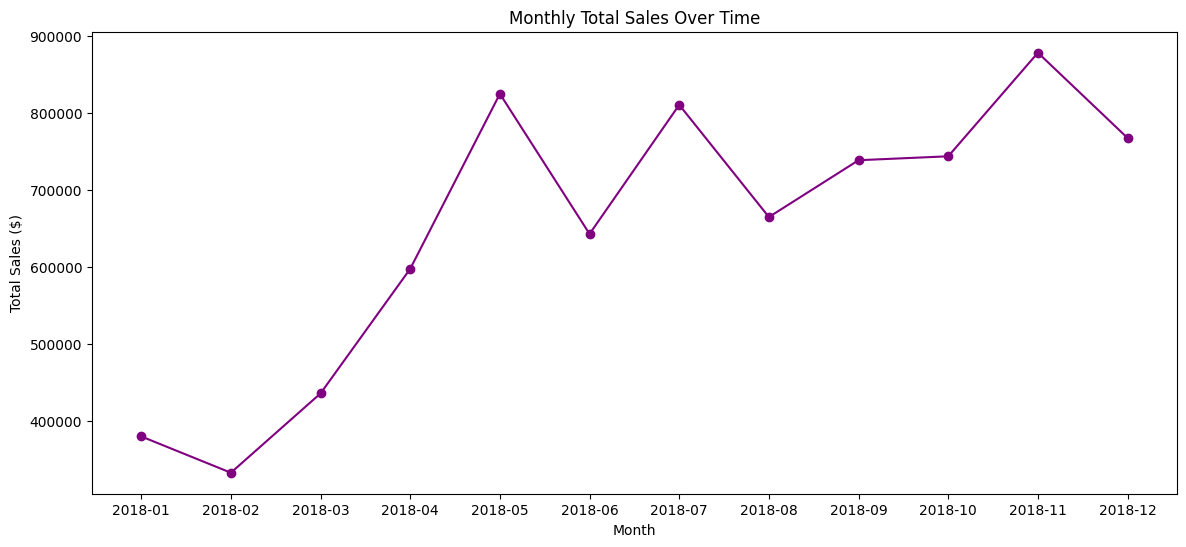

In [ ]:

monthly_sales = (
    sales_data
    .groupby(sales_data["order_date"].dt.to_period("M"))["sales"]
    .sum()
)


plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values, marker="o", c="purple"
)

plt.title("Monthly Total Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.show()



Продажі зростають протягом року, але не рівно: є місяці зі спадом і місяці з різким підйомом. Найкращі результати — ближче до кінця року.

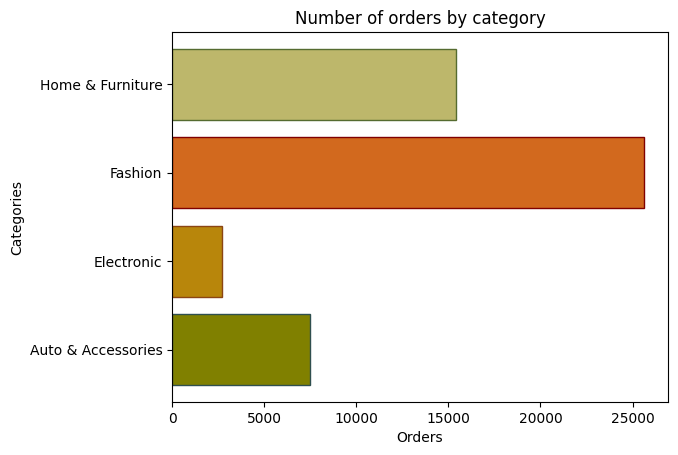

In [ ]:
orders_by_category = sales_data.groupby("product_category").size()

plt.barh(
    orders_by_category.index,
    orders_by_category.values,color=["olive", "darkgoldenrod", "chocolate", "darkkhaki"],
    edgecolor=["darkslategray","saddlebrown", "maroon","darkolivegreen"]
)
plt.title("Number of orders by category")
plt.xlabel("Orders")
plt.ylabel("Categories")
plt.show()

Найбільш популярними є товари категорії Fashion,а товари категорії Electronic мають найменший попит.

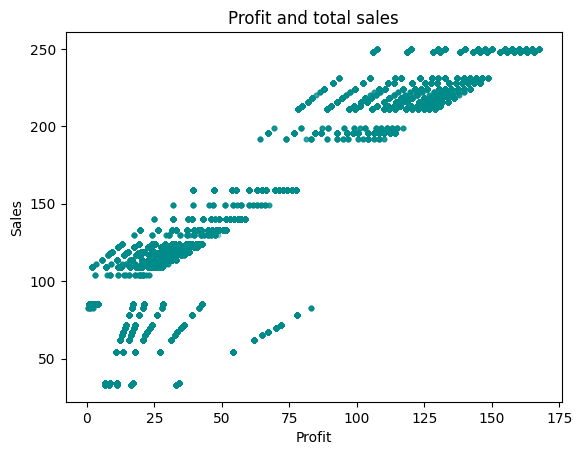

In [ ]:
plt.scatter(sales_data["profit"], sales_data["sales"], color="darkcyan",s=10, alpha=0.2)
plt.title("Profit and total sales")
plt.xlabel("Profit")
plt.ylabel("Sales")
plt.show()


Точкова діаграма показує сильний позитивний зв’язок між прибутком і ціною продажу.

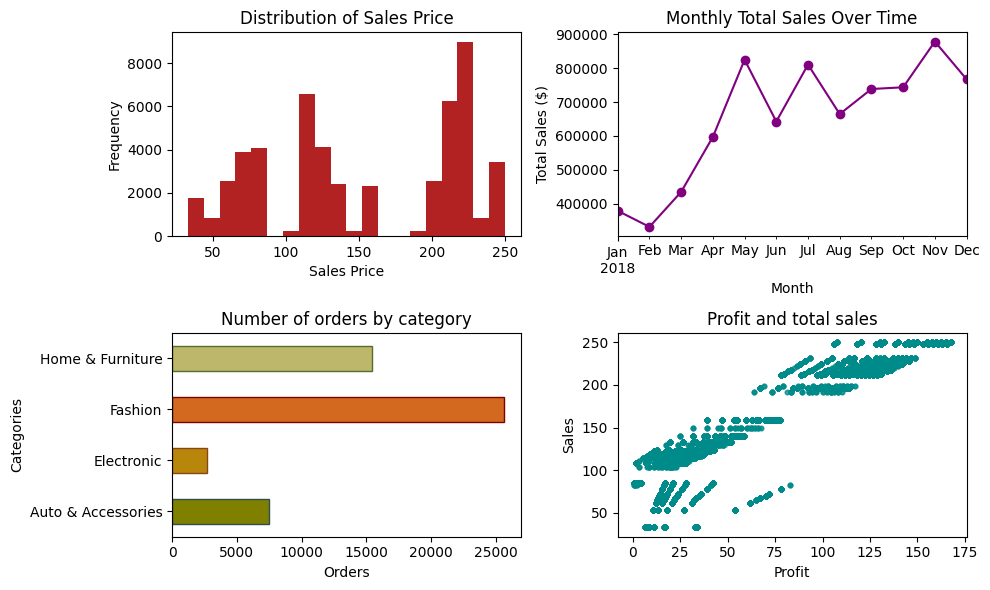

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(16,16))

ax[0, 0].hist(sales_data["sales"],bins=20, color="firebrick")
ax[0, 0].set_title("Distribution of Sales Price")
ax[0, 0].set_xlabel("Sales Price")
ax[0, 0].set_ylabel("Frequency")

sales_data.groupby(sales_data["order_date"].dt.to_period("M"))["sales"].sum().plot(kind="line",ax=ax[0, 1],
                                                                                   figsize=(10, 6),marker="o",color="purple")
ax[0, 1].set_title("Monthly Total Sales Over Time")
ax[0, 1].set_xlabel("Month")
ax[0, 1].set_ylabel("Total Sales ($)")


sales_data.groupby("product_category",observed=False ).size().plot(
    kind="barh", ax=ax[1, 0], color=["olive", "darkgoldenrod", "chocolate", "darkkhaki"],
    edgecolor=["darkslategray","saddlebrown", "maroon","darkolivegreen"]
)
ax[1, 0].set_title("Number of orders by category")
ax[1, 0].set_xlabel("Orders")
ax[1, 0].set_ylabel("Categories")


ax[1, 1].scatter(sales_data["profit"], sales_data["sales"], color="darkcyan",s=10, alpha=0.2)
ax[1, 1].set_title("Profit and total sales")
ax[1, 1].set_xlabel("Profit")
ax[1, 1].set_ylabel("Sales")

plt.tight_layout()
plt.show()


